In [1]:
# # mount on google drive
# from google.colab import drive
# drive.mount('/content/drive/')
# # go to your code files directory
# import os
# os.chdir("/content/drive/My Drive/WatNet/dataloader")


## 1. Data loading
## 1.1. Loading from data path

In [2]:
import os
os.chdir('..')
from notebooks import config
import glob
import time
from utils.imgShow import imsShow
import tensorflow as tf
import matplotlib.pyplot as plt 
from dataloader.img_aug import img_aug
from dataloader.path_io import read_scene_pair, crop_patches
from dataloader.tfrecord_io import parse_image, parse_shape, toPatchPair


In [6]:
paths_scene = sorted(glob.glob('data/dset-s2/scene/*'))
paths_truth = sorted(glob.glob('data/dset-s2/truth/*'))

##### ------- 1. Scenes to Patches ------ ####
######################################################
## ----- train data ----- ##
tra_scenes, tra_truths = read_scene_pair(paths_scene=paths_scene[0:-30], 
                                            paths_truth=paths_truth[0:-30])
tra_patches, tra_truths = crop_patches(tra_scenes, tra_truths)
## ----- validation data ----- ##
val_scenes, val_truths = read_scene_pair(paths_scene=paths_scene[-30:], 
                                            paths_truth=paths_truth[-30:])
val_patches, val_truths = crop_patches(val_scenes, val_truths)


In [7]:
##### ------- 2. Patches -> Batches ------ ####
## -----train data----- ##
tra_dset = tf.data.Dataset.from_tensor_slices((tra_patches, tra_truths))\
                .map(img_aug)
tra_dset = tra_dset.batch(config.batch_size).shuffle(config.buffer_size)
## -----val data----- ##
val_dset = tf.data.Dataset.from_tensor_slices((val_patches, val_truths))\
                .map(img_aug)
val_dset = val_dset.batch(config.batch_size)
print('tra_dset:', tra_dset)
print('val_dset:', val_dset)


tra_dset: <ShuffleDataset shapes: ((None, 512, 512, 6), (None, 512, 512, 1)), types: (tf.float32, tf.float32)>
val_dset: <BatchDataset shapes: ((None, 512, 512, 6), (None, 512, 512, 1)), types: (tf.float32, tf.float32)>


## 1.2. Loading from tfrecord

In [5]:
# ### Data loading from .tfrecord file
# path_tra_data = 'data/tfrecord-s2/tra_data.tfrecords'
# path_val_data = 'data/tfrecord-s2/val_data.tfrecords'
# ## ----- training data ----- ##
# tra_dset = tf.data.TFRecordDataset(path_tra_data)
# tra_dset = tra_dset.map(parse_image).map(parse_shape)\
#             .cache()\
#             .map(toPatchPair)\
#             .map(img_aug)
# tra_dset = tra_dset.shuffle(config.buffer_size).batch(config.batch_size)

# ## ----- validation data ----- ##
# val_dset = tf.data.TFRecordDataset(path_val_data)
# val_dset = val_dset.map(parse_image).map(parse_shape)\
#             .map(toPatchPair)
# val_dset = val_dset.batch(32)
# print('tra_dset:', tra_dset)
# print('val_dset:', val_dset)


tra_dset: <BatchDataset shapes: ((None, 512, 512, 6), (None, 512, 512, 1)), types: (tf.float32, tf.float32)>
val_dset: <BatchDataset shapes: ((None, 512, 512, 6), (None, 512, 512, 1)), types: (tf.float32, tf.float32)>


## 1. Check the dataset

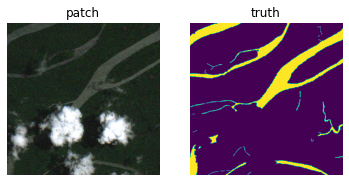

num_scene: 65
time: 1.5957982540130615


In [14]:
# for i in range(5):
start = time.time()
i_batch = i_scene = 0
for patch, truth in tra_dset:
    i_batch += 1
    i_scene += patch.shape[0]

imsShow(img_list=[patch[0], truth[0]], 
        img_name_list=['patch', 'truth'],
        clip_list=[2,0]
        )

plt.show()
print('num_scene:', i_scene)
print('time:', time.time()-start)
